# 03 - Model Training (baseline)
Trains a Logistic Regression baseline on the **saved** train split and saves the model.
We never re-split the data here, so the test set stays untouched.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))   # so we can import from src/

import joblib
from src import config
from src.data_preprocessing import load_processed_data

X_train, X_test, y_train, y_test = load_processed_data()
print(X_train.shape, X_test.shape)
print("Default rate  train:", round(y_train.mean(), 3), " test:", round(y_test.mean(), 3))

(24000, 29) (6000, 29)
Default rate  train: 0.221  test: 0.221


### Handle class imbalance (train data only)
Only ~22% of customers default. SMOTE creates synthetic default examples in the **training** set only.

In [2]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=config.RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("After SMOTE:", y_train_sm.value_counts().to_dict())

After SMOTE: {0: 18691, 1: 18691}


In [3]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_sm, y_train_sm)
print(model)

LogisticRegression(class_weight='balanced', max_iter=1000)


C:\Users\Ananya\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Evaluate on the untouched test set

In [4]:
from sklearn.metrics import roc_auc_score, classification_report

y_pred_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_prob), 4))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.7013
              precision    recall  f1-score   support

           0       0.87      0.73      0.79      4673
           1       0.38      0.60      0.47      1327

    accuracy                           0.70      6000
   macro avg       0.62      0.66      0.63      6000
weighted avg       0.76      0.70      0.72      6000



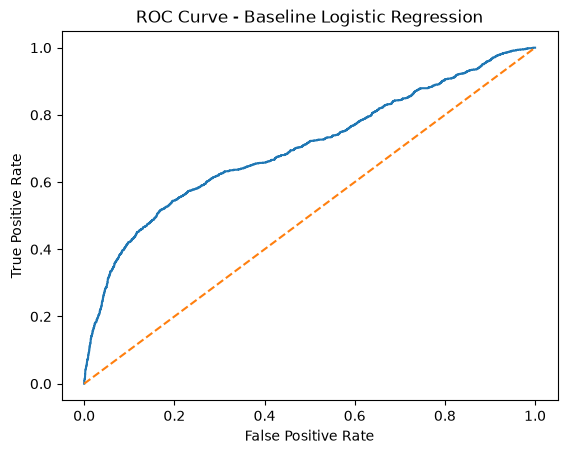

In [5]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline Logistic Regression")
plt.show()

### Save the model (one file only)

In [6]:
config.MODEL_PATH.parent.mkdir(exist_ok=True)
joblib.dump(model, config.MODEL_PATH)
print("Model saved at", config.MODEL_PATH)

Model saved at C:\Users\Ananya\Cash-or-Crash\models\credit_model.joblib
